In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from google.colab import files
import os
import seaborn as sns

In [ ]:
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
cd gdrive/MyDrive/finalized_data

/content/gdrive/MyDrive/finalized_data


In [ ]:
df1 = pd.read_csv("Station1_simulated_cleaned_merged_data.csv", sep = ",", parse_dates = ['Unnamed: 0'], index_col = 'Unnamed: 0')
df2 = pd.read_csv("Station2_simulated_cleaned_merged_data.csv", sep = ",", parse_dates = ['Unnamed: 0'], index_col = 'Unnamed: 0')
df3 = pd.read_csv("Station3_simulated_cleaned_merged_data.csv", sep = ",", parse_dates = ['Unnamed: 0'], index_col = 'Unnamed: 0')
df4 = pd.read_csv("Station4_simulated_cleaned_merged_data.csv", sep = ",", parse_dates = ['Unnamed: 0'], index_col = 'Unnamed: 0')
df5 = pd.read_csv("Station5_simulated_cleaned_merged_data.csv", sep = ",", parse_dates = ['Unnamed: 0'], index_col = 'Unnamed: 0')
df6 = pd.read_csv("Station6_simulated_cleaned_merged_data.csv", sep = ",", parse_dates = ['Unnamed: 0'], index_col = 'Unnamed: 0')

df1.index = pd.to_datetime(df1.index)
df2.index = pd.to_datetime(df2.index)
df3.index = pd.to_datetime(df3.index)
df4.index = pd.to_datetime(df4.index)
df5.index = pd.to_datetime(df5.index)
df6.index = pd.to_datetime(df6.index)

In [ ]:
dfList = [df1, df2, df3, df4, df5, df6]
labels = ['df1', 'df2', 'df3', 'df4', 'df5', 'df6']

In [ ]:
features = ['SWC_5','SWC_10','SWC_20','SWC_50']

# create a new DataFrame to hold all scaled features
feature_table_1 = pd.DataFrame(index = df1.index)

for i, df in enumerate(dfList, start = 1):
    for feature in features:
      if (i == 1):
        new_feature_name = f"{feature}_Station{i}"
        feature_table_1[new_feature_name] = df[feature]

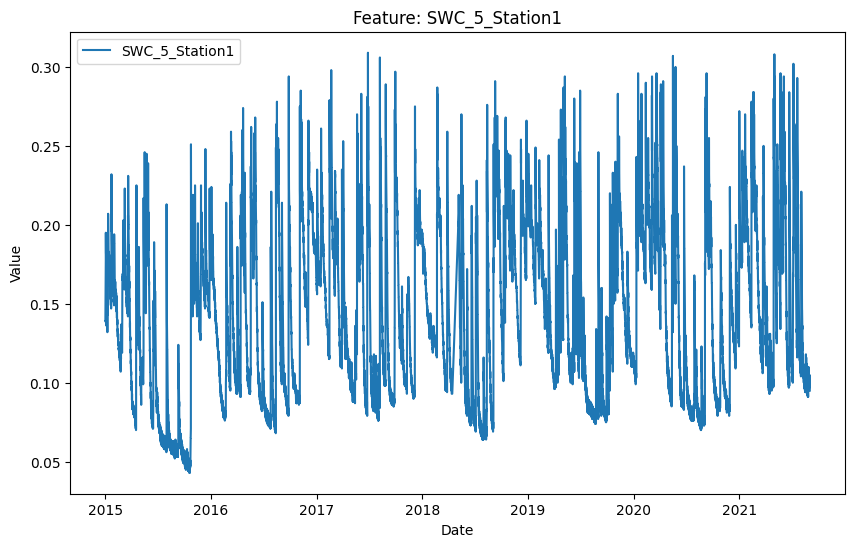

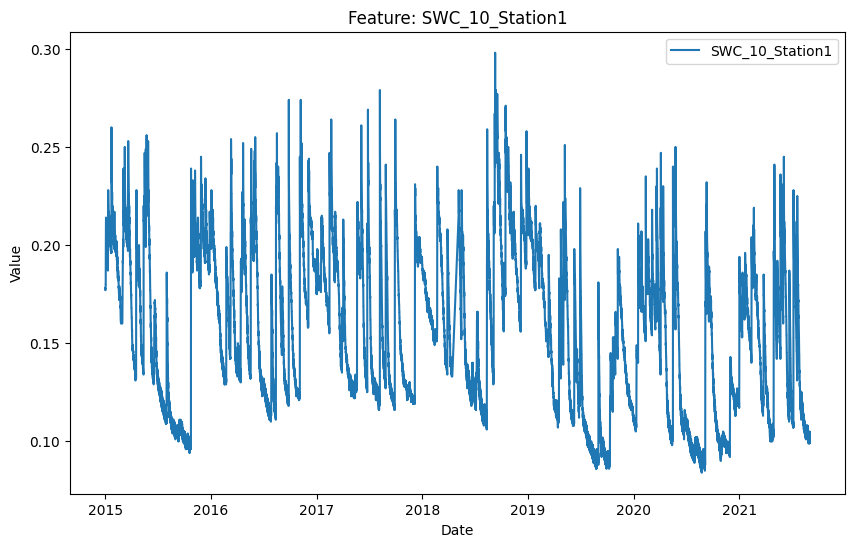

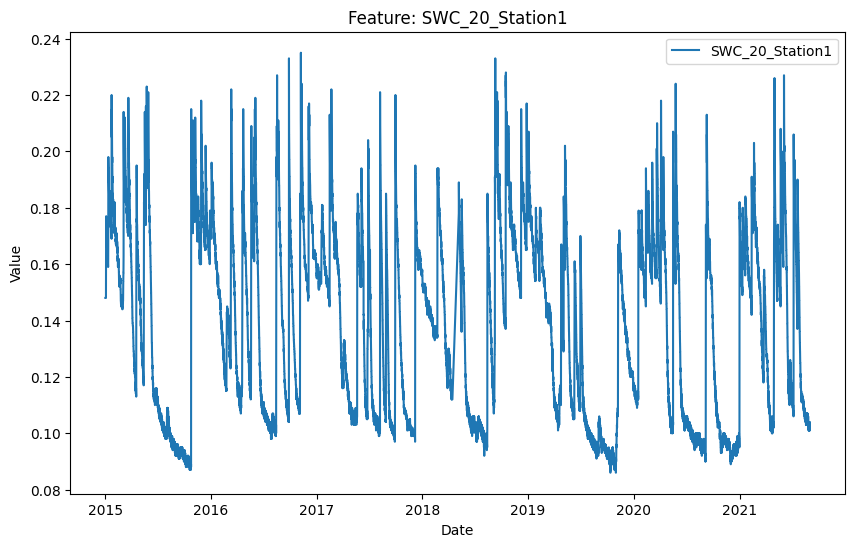

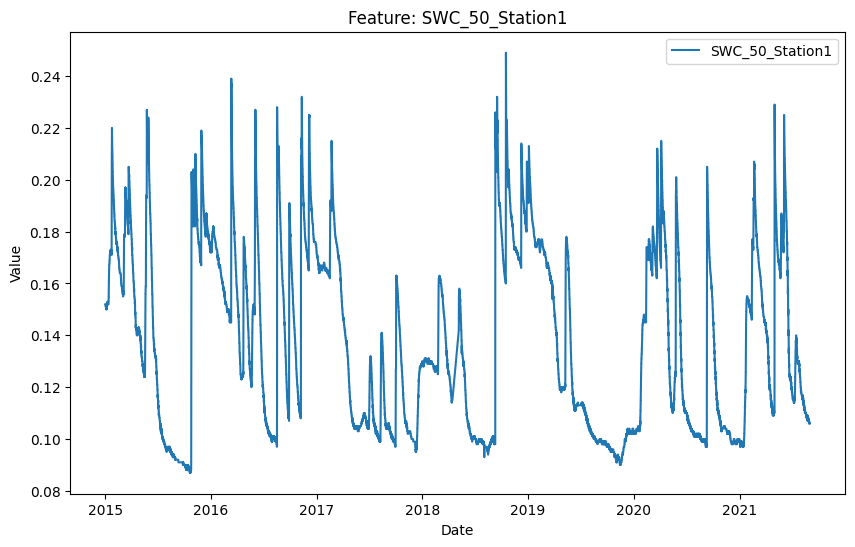

In [ ]:
# Visualize original features
for feature in feature_table_1.columns:
    plt.figure(figsize = (10, 6))
    plt.plot(feature_table_1.index, feature_table_1[feature], label = feature)
    plt.title(f"Feature: {feature}")
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

In [ ]:
# create new feature table with 240-step (10-day) moving averages
# first 239 records for each feature are computed using expanding mean (i.e. mean of all records up until current record)

for feature in feature_table_1.columns:
    expanding_mean = feature_table_1[feature].expanding().mean()
    rolling_mean = feature_table_1[feature].rolling(window = 240).mean()
    combined_mean = rolling_mean.fillna(expanding_mean) # first (window - 1) records are filled with expanding_mean values
    feature_table_1[feature] = combined_mean

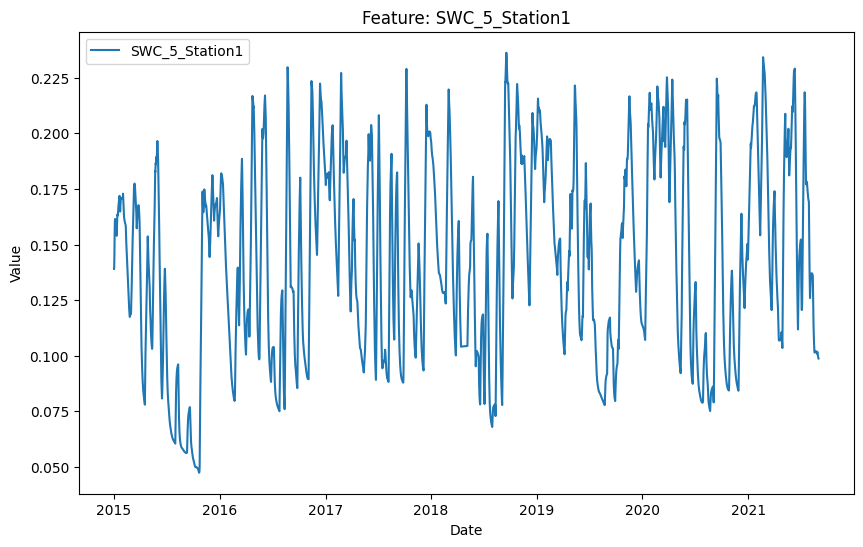

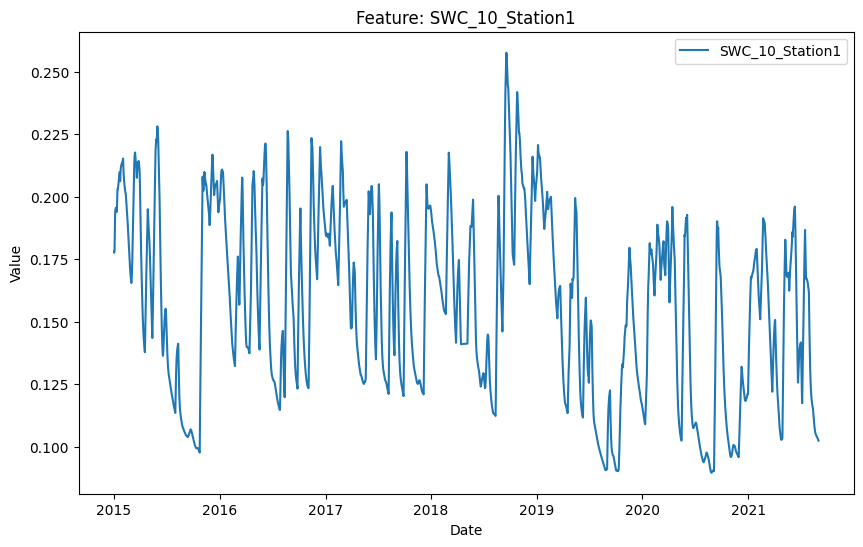

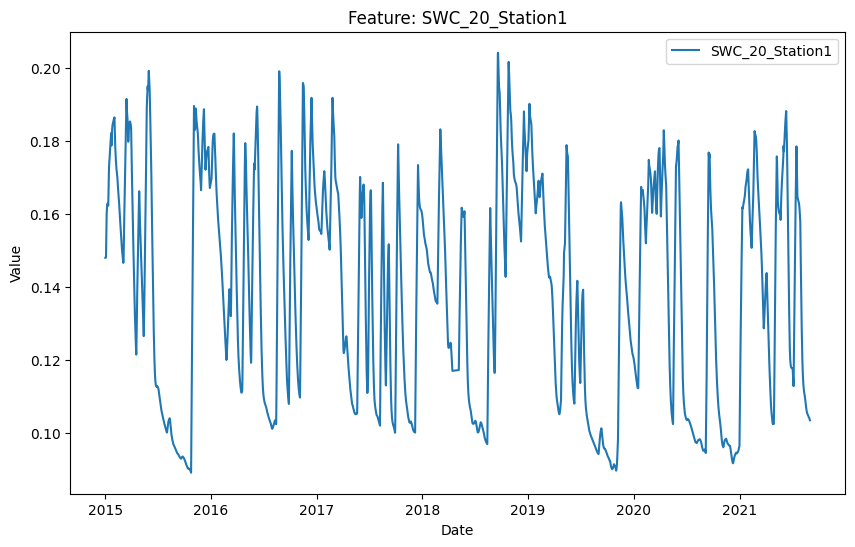

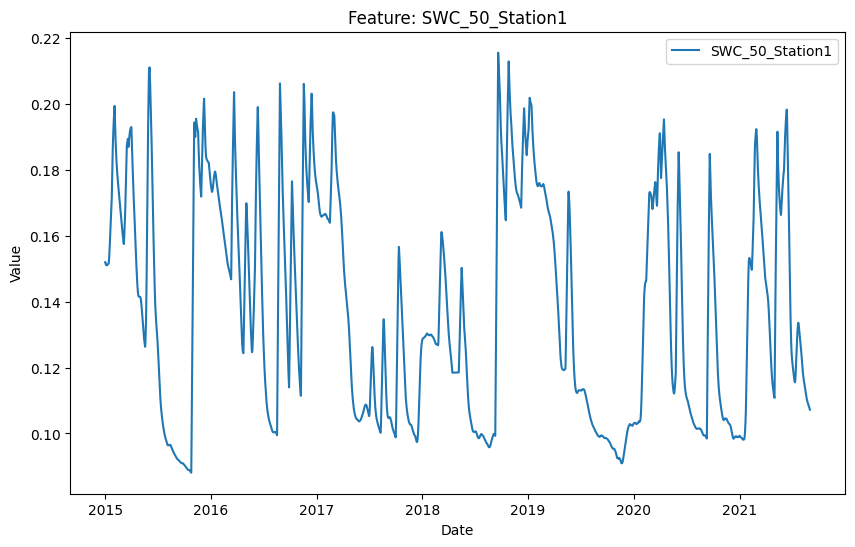

In [ ]:
# visualize features with moving average incorporated
for feature in feature_table_1.columns:
    plt.figure(figsize = (10, 6))
    plt.plot(feature_table_1.index, feature_table_1[feature], label = feature)
    plt.title(f"Feature: {feature}")
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

In [ ]:
corr_features = ['Ppt','T_5','T_10','T_20','T_50','Srad']

# create a new DataFrame to hold all scaled features
corr_feature_table_1 = pd.DataFrame(index = df1.index)

for i, df in enumerate(dfList, start = 1):
    for corr_feature in corr_features:
      if (i == 1):
        new_feature_name = f"{corr_feature}_Station{i}"
        corr_feature_table_1[new_feature_name] = df[corr_feature]
    break

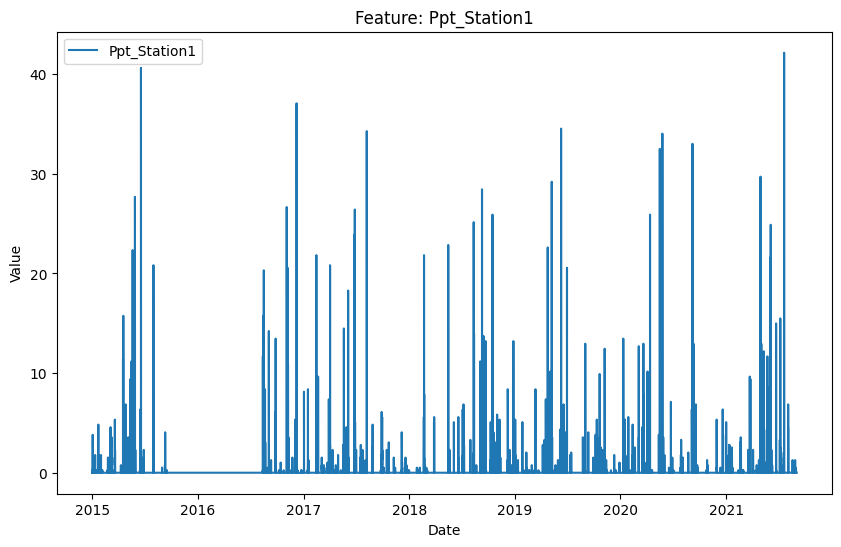

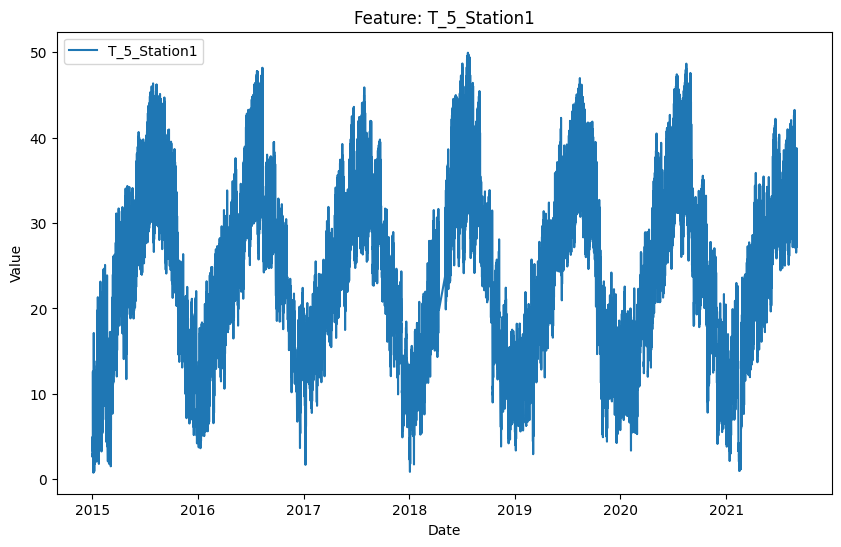

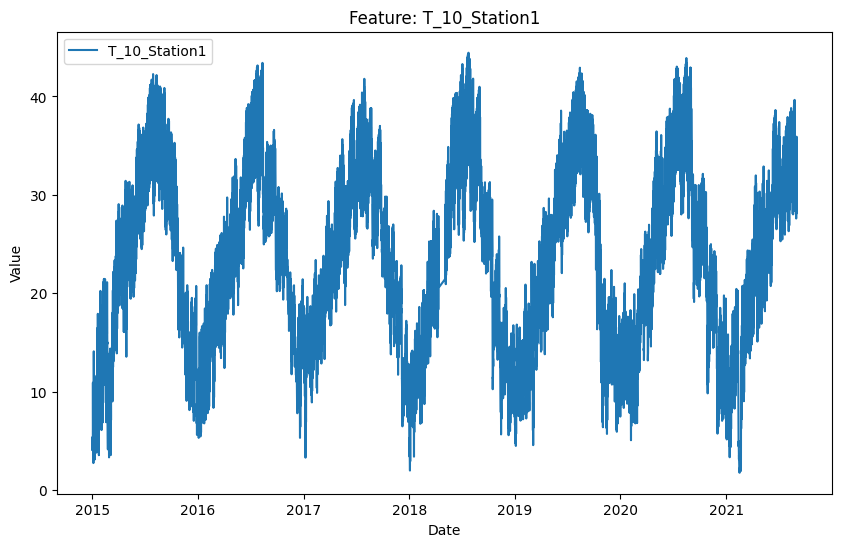

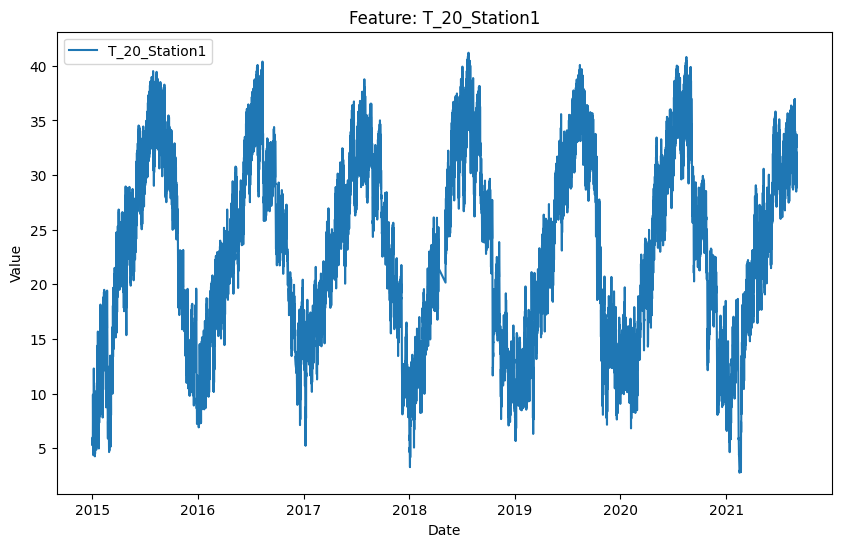

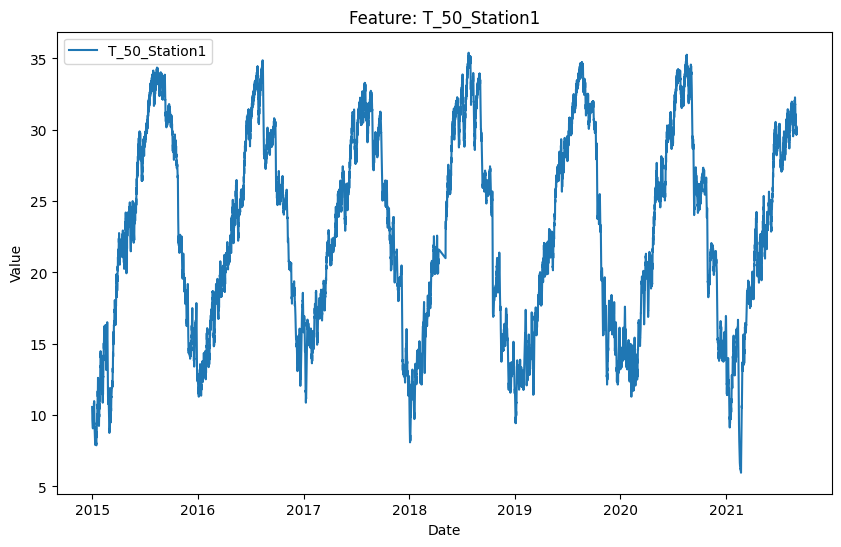

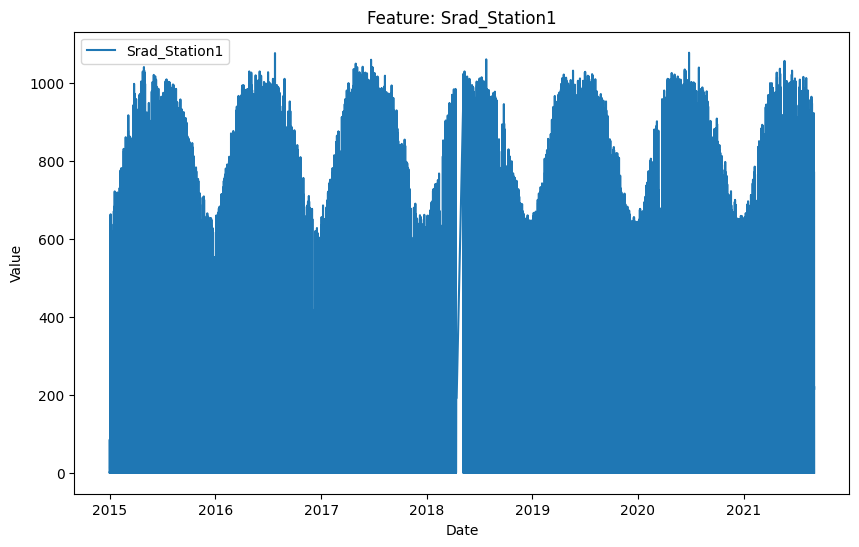

In [ ]:
# visualize original features
for corr_feature in corr_feature_table_1.columns:
    plt.figure(figsize = (10, 6))
    plt.plot(corr_feature_table_1.index, corr_feature_table_1[corr_feature], label = corr_feature)
    plt.title(f"Feature: {corr_feature}")
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

In [ ]:
# create new feature table with 240-step (10-day) moving averages
# first 239 records for each feature are computed using expanding mean (i.e. mean of all records up until current record)

for corr_feature in corr_feature_table_1.columns:
    expanding_mean = corr_feature_table_1[corr_feature].expanding().mean()
    rolling_mean = corr_feature_table_1[corr_feature].rolling(window = 240).mean()
    combined_mean = rolling_mean.fillna(expanding_mean) # first (window - 1) records are filled with expanding_mean values
    corr_feature_table_1[corr_feature] = combined_mean

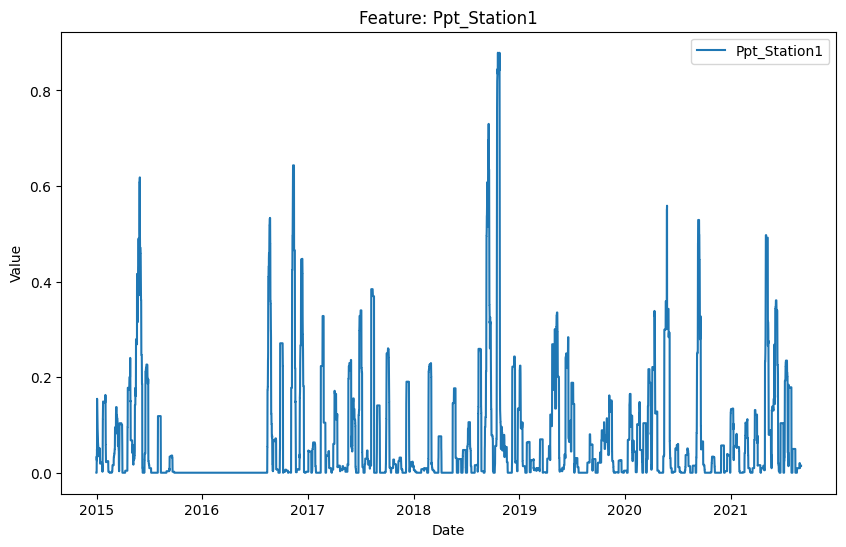

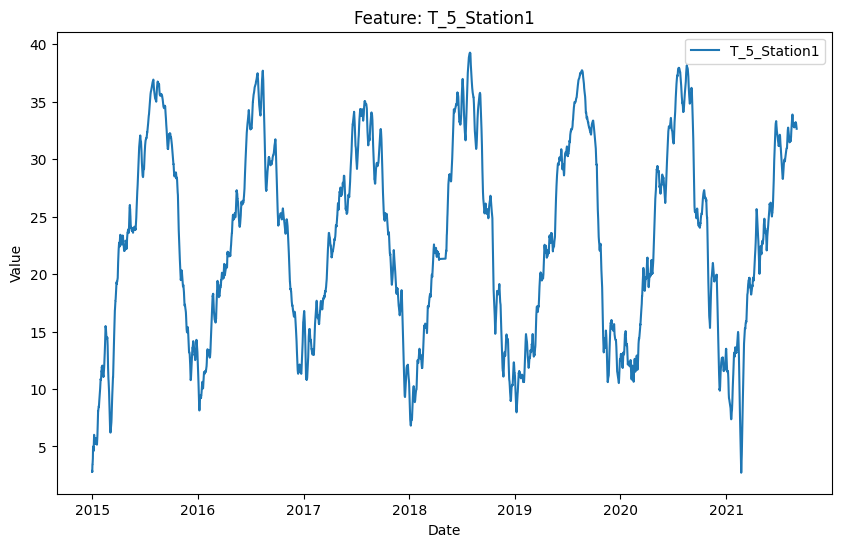

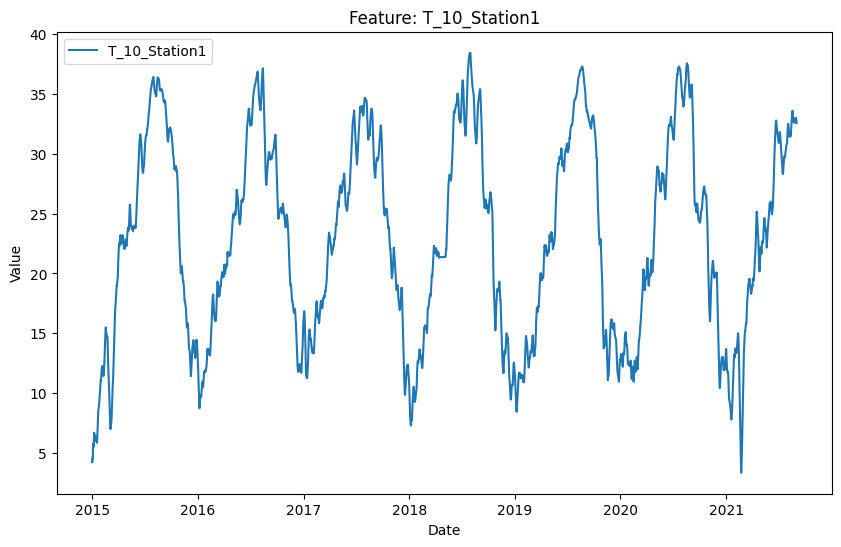

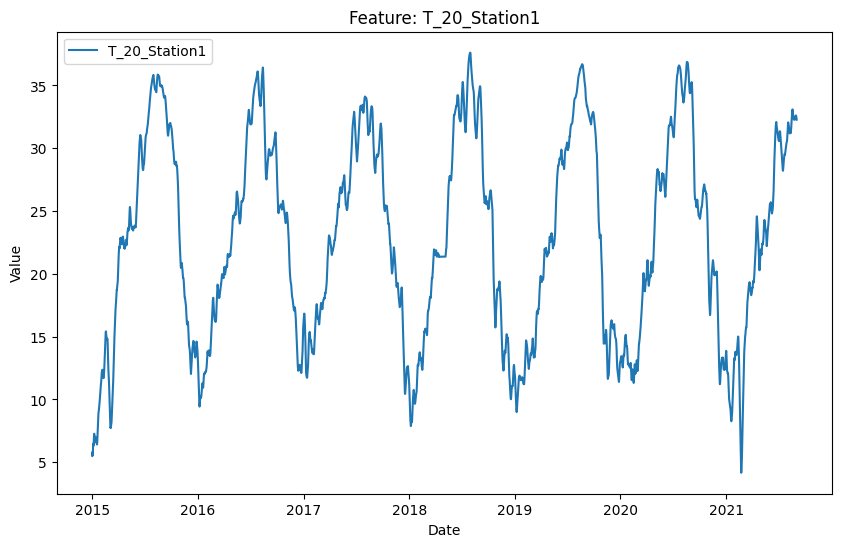

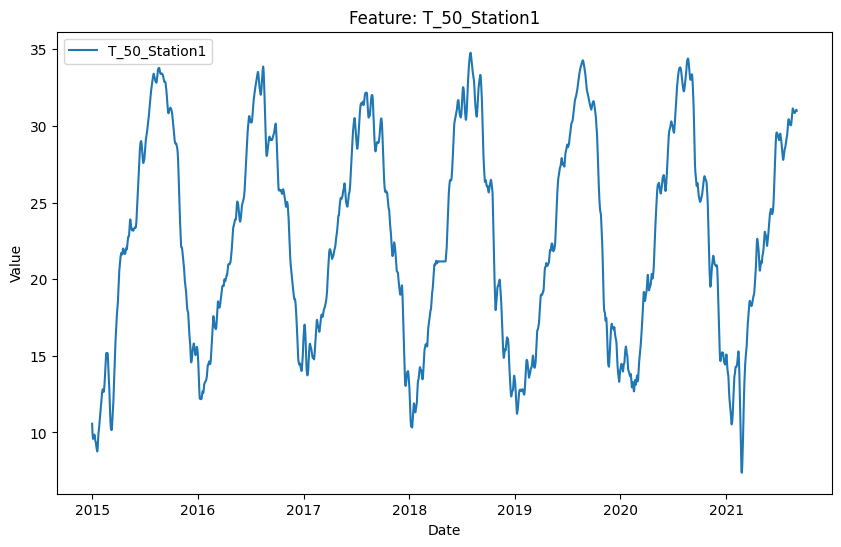

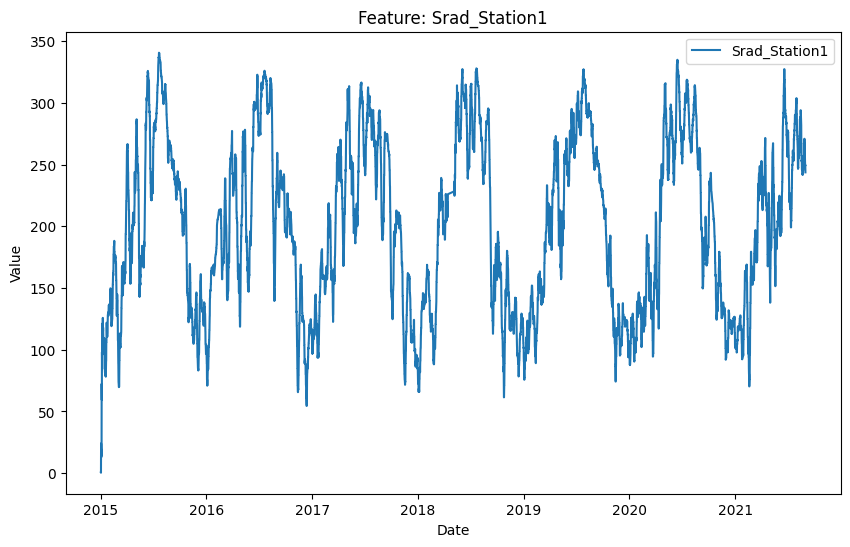

In [ ]:
# visualize features with moving average incorporated
for corr_feature in corr_feature_table_1.columns:
    plt.figure(figsize = (10, 6))
    plt.plot(corr_feature_table_1.index, corr_feature_table_1[corr_feature], label = corr_feature)
    plt.title(f"Feature: {corr_feature}")
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

In [ ]:
# helper function to create sequences from the data
def create_sequences(data, n_steps, step_size):
    X = []
    start_indices = []
    for i in range(0, len(data) - n_steps, step_size):
        X.append(data[i:i+n_steps])
        start_indices.append(i)
    return np.array(X), np.array(start_indices)

In [ ]:
def normalize_data(data):
    # normalize each feature to value betweeen 0 and 1
    scaler = MinMaxScaler(feature_range = (0, 1))
    scaled_data = scaler.fit_transform(data.reshape(-1, 1))
    return scaled_data, scaler

In [ ]:
# original time series and anomaly visualization
def original_anomaly_plot(original_data, anomaly_indices, anomaly_dates, anomaly_values, feature_name):
  plt.figure(figsize = (15, 6))
  plt.plot(df.index, original_data, label = 'Original Data', color = 'blue', alpha = 0.5)
  if len(anomaly_indices) > 0:
      plt.scatter(anomaly_dates, anomaly_values, color = 'red', label = 'Anomaly', alpha = 0.75)
  plt.xlabel('Date')
  plt.ylabel(feature_name)
  plt.title(f'{feature_name} Data and Detected Anomalies')
  plt.legend()
  plt.show()

In [ ]:
# autoencoder reconstruction visualization
def autoencoder_reconstruction_plot(reconstructed_data, feature_name, plot_dates):
    plt.figure(figsize = (15, 6))
    plt.plot(plot_dates, reconstructed_data, label = 'Reconstructed Data', color = 'orange', alpha = 0.75)
    plt.xlabel('Date')
    plt.ylabel('Reconstructed Value')
    plt.title(f'Reconstructed {feature_name} Over Time')
    plt.legend()
    plt.show()

In [ ]:
# original time series, anomaly, & autoencoder reconstruction visualization
def anomaly_reconstruction_plot(original_data, reconstructed_data, anomaly_indices, anomaly_dates, anomaly_values, feature_name, plot_dates):
    plt.figure(figsize = (15, 6))
    plt.plot(df.index, original_data, label = 'Original Data', color = 'blue', alpha = 0.5)
    plt.plot(plot_dates, reconstructed_data, label = 'Reconstructed Data', color = 'orange', alpha = 0.75)
    if len(anomaly_indices) > 0:
        plt.scatter(anomaly_dates, anomaly_values, color = 'red', label = 'Anomaly', alpha = 0.75)
    plt.xlabel('Date')
    plt.ylabel(feature_name)
    plt.title(f'Reconstruction and Anomalies for {feature_name}')
    plt.legend()
    plt.show()

In [ ]:
# original time series, graded anomalies, & autoencoder reconstruction visualization
def graded_anomaly_plot(original_data, reconstructed_data, reconstruction_error, anomaly_indices, anomaly_dates, anomaly_values, feature_name, plot_dates):
    plt.figure(figsize = (15, 6))
    plt.plot(df.index, original_data, label = 'Original Data', color = 'blue', alpha = 0.5)
    plt.plot(plot_dates, reconstructed_data, label = 'Reconstructed Data', color = 'orange', alpha = 0.75)
    if len(anomaly_indices) > 0:
      plt.scatter(anomaly_dates, anomaly_values, c = reconstruction_error[anomaly_indices], cmap = 'winter', label = 'Anomaly', alpha = 0.75)
    plt.colorbar(label = 'Anomaly Strength (Reconstruction Error)')
    plt.xlabel('Date')
    plt.ylabel(feature_name)
    plt.title(f'Reconstruction and Graded Anomalies for {feature_name}')
    plt.legend()
    plt.show()

In [ ]:
# plot overall feature distribution vs. feature distribution in 10 days before anomaly
def anomaly_distribution_plot(feature_name, anomaly_indices, end_indices):
    # filter for features related to the specified station
    station_number = feature_name.split('_')[-1]
    station_features = [col for col in corr_feature_table_1.columns if col.endswith(station_number)]

    for anomaly_index in anomaly_indices:
        anomaly_date = df.index[end_indices[anomaly_index]]

        # account for edge case where anomaly occurs within first 10 days
        start_date = df.index[0]
        start_date = max(anomaly_date - pd.Timedelta(days = 10), start_date)

        pre_anomaly_data = corr_feature_table_1.loc[start_date : anomaly_date]

        # subplots for each feature
        n_features = len(station_features)
        n_cols = 3
        n_rows = np.ceil(n_features / n_cols).astype(int)

        plt.figure(figsize = (5 * n_cols, 5 * n_rows))
        plt.suptitle(f'Feature Distribution around Anomaly on {anomaly_date.strftime("%Y-%m-%d")}', fontsize = 16)

        for i, feature in enumerate(station_features, 1):
            plt.subplot(n_rows, n_cols, i)

            # plot overall feature distribution vs. feature distribution in 10 days before anomaly - boxplot code
            overall_data = corr_feature_table_1[feature]
            pre_anomaly_feature_data = pre_anomaly_data[feature]
            plot_data = pd.DataFrame({
                feature: pd.concat([overall_data, pre_anomaly_feature_data]),
                'Category': ['Overall' for _ in range(len(overall_data))] + ['Pre-Anomaly' for _ in range(len(pre_anomaly_feature_data))]
            })

            sns.boxplot(x = 'Category', y = feature, data = plot_data)
            plt.title(f'{feature} around Anomaly on {anomaly_date.strftime("%Y-%m-%d")}')

        plt.tight_layout()
        plt.show()

In [ ]:
# 10-day sequences, 1-day steps
def train_visualize(df, feature_name, n_steps = 240, epochs = 100, batch_size = 128, step_size = 24):
    feature_data = df[feature_name].values.reshape(-1, 1)
    scaler = MinMaxScaler(feature_range = (0, 1))
    scaled_data = scaler.fit_transform(feature_data)

    # store start_indices for visualizations
    X, start_indices = create_sequences(scaled_data, n_steps = n_steps, step_size = step_size)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    # LSTM autoencoder model
    model = Sequential([
        Bidirectional(LSTM(128, activation = 'relu', input_shape = (n_steps, 1), return_sequences = True)),
        Bidirectional(LSTM(64, activation = 'relu', return_sequences = False)),
        RepeatVector(n_steps),
        Bidirectional(LSTM(64, activation = 'relu', return_sequences = True)),
        Bidirectional(LSTM(128, activation = 'relu', return_sequences = True)),
        TimeDistributed(Dense(1))
    ])
    model.compile(optimizer = Adam(learning_rate = 0.00002), loss = 'mse')

    # stop training when performance plateaus
    early_stopping = EarlyStopping(monitor = 'val_loss', patience = 20, mode = 'min', verbose = 1, restore_best_weights = True)
    history = model.fit(X, X, epochs = epochs, batch_size = batch_size, validation_split = 0.2, shuffle = True, callbacks = [early_stopping])

    X_pred = model.predict(X)
    reconstruction_error = np.mean(np.abs(X_pred - X), axis = 1).flatten()

    # threshold for anomaly detection
    threshold = np.mean(reconstruction_error) + 2 * np.std(reconstruction_error)
    anomalies = reconstruction_error > threshold

    # mapping sequences back to dates
    end_indices = start_indices + n_steps - 1
    plot_dates = df.index[end_indices]
    original_data = scaler.inverse_transform(scaled_data).flatten()
    anomaly_indices = np.where(anomalies)[0]
    anomaly_dates = plot_dates[anomaly_indices]
    anomaly_values = original_data[end_indices[anomaly_indices]]

    # original time series and anomaly visualization
    original_anomaly_plot(original_data, anomaly_indices, anomaly_dates, anomaly_values, feature_name)

    # autoencoder reconstruction visualization
    reconstructed_data = scaler.inverse_transform(X_pred[:, -1, :]).flatten()
    autoencoder_reconstruction_plot(reconstructed_data, feature_name, plot_dates)

    # original time series, anomaly, & autoencoder reconstruction visualization
    anomaly_reconstruction_plot(original_data, reconstructed_data, anomaly_indices, anomaly_dates, anomaly_values, feature_name, plot_dates)

    # original time series, graded anomalies, & autoencoder reconstruction visualization
    graded_anomaly_plot(original_data, reconstructed_data, reconstruction_error, anomaly_indices, anomaly_dates, anomaly_values, feature_name, plot_dates)

    # anomaly feature distribution visualization
    anomaly_distribution_plot(feature_name, anomaly_indices, end_indices)

In [ ]:
train_visualize(feature_table_1, 'SWC_5_Station1')

In [ ]:
train_visualize(feature_table_1, 'SWC_10_Station1')

In [ ]:
train_visualize(feature_table_1, 'SWC_20_Station1')

In [ ]:
train_visualize(feature_table_1, 'SWC_50_Station1')

Epoch 1/100
14/16 [=========================>....] - ETA: 4s - loss: 0.2397